In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('./'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

./test.csv
./train.csv
./churn-predication.ipynb


In [25]:
pip install yreport

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Importing DataSet

In [4]:
train,test = pd.read_csv('train.csv') , pd.read_csv('test.csv')

## EDA and Cleaning

In [5]:
from yreport import data_health_report

In [6]:
health_train = data_health_report(train).summary()

Data Health Score: 100.0/100
Rows: 594194 | No_Columns: 21

Numeric Columns : ['MonthlyCharges', 'SeniorCitizen', 'TotalCharges', 'id', 'tenure']
Categorical Columns : ['Churn', 'Contract', 'Dependents', 'DeviceProtection', 'InternetService', 'MultipleLines', 'OnlineBackup', 'OnlineSecurity', 'PaperlessBilling', 'Partner', 'PaymentMethod', 'PhoneService', 'StreamingMovies', 'StreamingTV', 'TechSupport', 'gender']
DateTime Columns : []

Missing Percentage: 

Warnings:

Recommendations:
- encoding: {'Churn': {'action': 'required', 'message': 'Categorical encoding required', 'confidence': 'MEDIUM'}, 'Contract': {'action': 'required', 'message': 'Categorical encoding required', 'confidence': 'MEDIUM'}, 'Dependents': {'action': 'required', 'message': 'Categorical encoding required', 'confidence': 'MEDIUM'}, 'DeviceProtection': {'action': 'required', 'message': 'Categorical encoding required', 'confidence': 'MEDIUM'}, 'InternetService': {'action': 'required', 'message': 'Categorical encoding

In [7]:
health_test = data_health_report(test).summary()

Data Health Score: 100.0/100
Rows: 254655 | No_Columns: 20

Numeric Columns : ['MonthlyCharges', 'SeniorCitizen', 'TotalCharges', 'id', 'tenure']
Categorical Columns : ['Contract', 'Dependents', 'DeviceProtection', 'InternetService', 'MultipleLines', 'OnlineBackup', 'OnlineSecurity', 'PaperlessBilling', 'Partner', 'PaymentMethod', 'PhoneService', 'StreamingMovies', 'StreamingTV', 'TechSupport', 'gender']
DateTime Columns : []

Missing Percentage: 

Warnings:

Recommendations:
- encoding: {'Contract': {'action': 'required', 'message': 'Categorical encoding required', 'confidence': 'MEDIUM'}, 'Dependents': {'action': 'required', 'message': 'Categorical encoding required', 'confidence': 'MEDIUM'}, 'DeviceProtection': {'action': 'required', 'message': 'Categorical encoding required', 'confidence': 'MEDIUM'}, 'InternetService': {'action': 'required', 'message': 'Categorical encoding required', 'confidence': 'MEDIUM'}, 'MultipleLines': {'action': 'required', 'message': 'Categorical encoding 

In [20]:
import pandas as pd
from ydata_profiling import ProfileReport


In [21]:
profile = ProfileReport(train, title="Profiling Report")


In [ ]:
profile

## Numeric Column Analysis

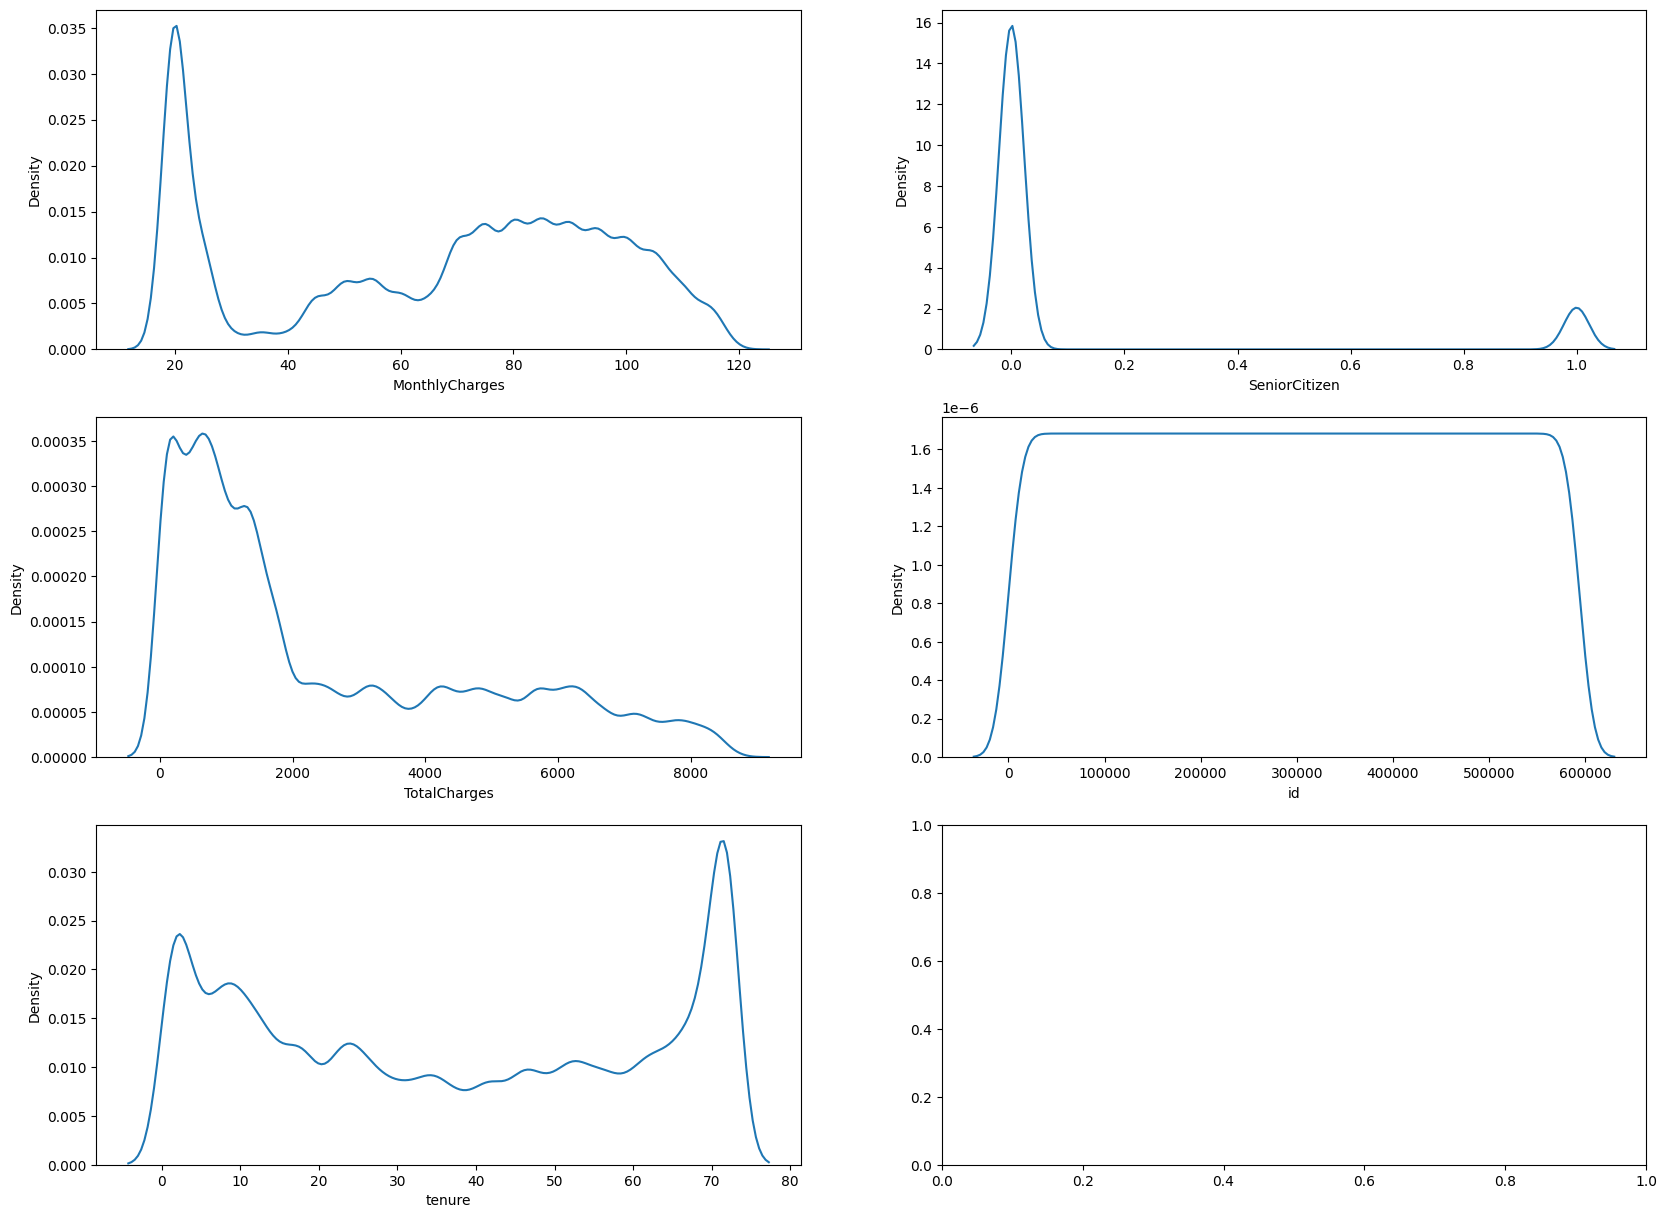

In [8]:
fig,ax = plt.subplots(3,2,figsize=(20,15))

cols = ['MonthlyCharges', 'SeniorCitizen', 'TotalCharges', 'id', 'tenure']

ax = ax.flatten()  

for i, col in enumerate(cols):
    sns.kdeplot(train[col], ax=ax[i])
    ax[i].set_xlabel(col)

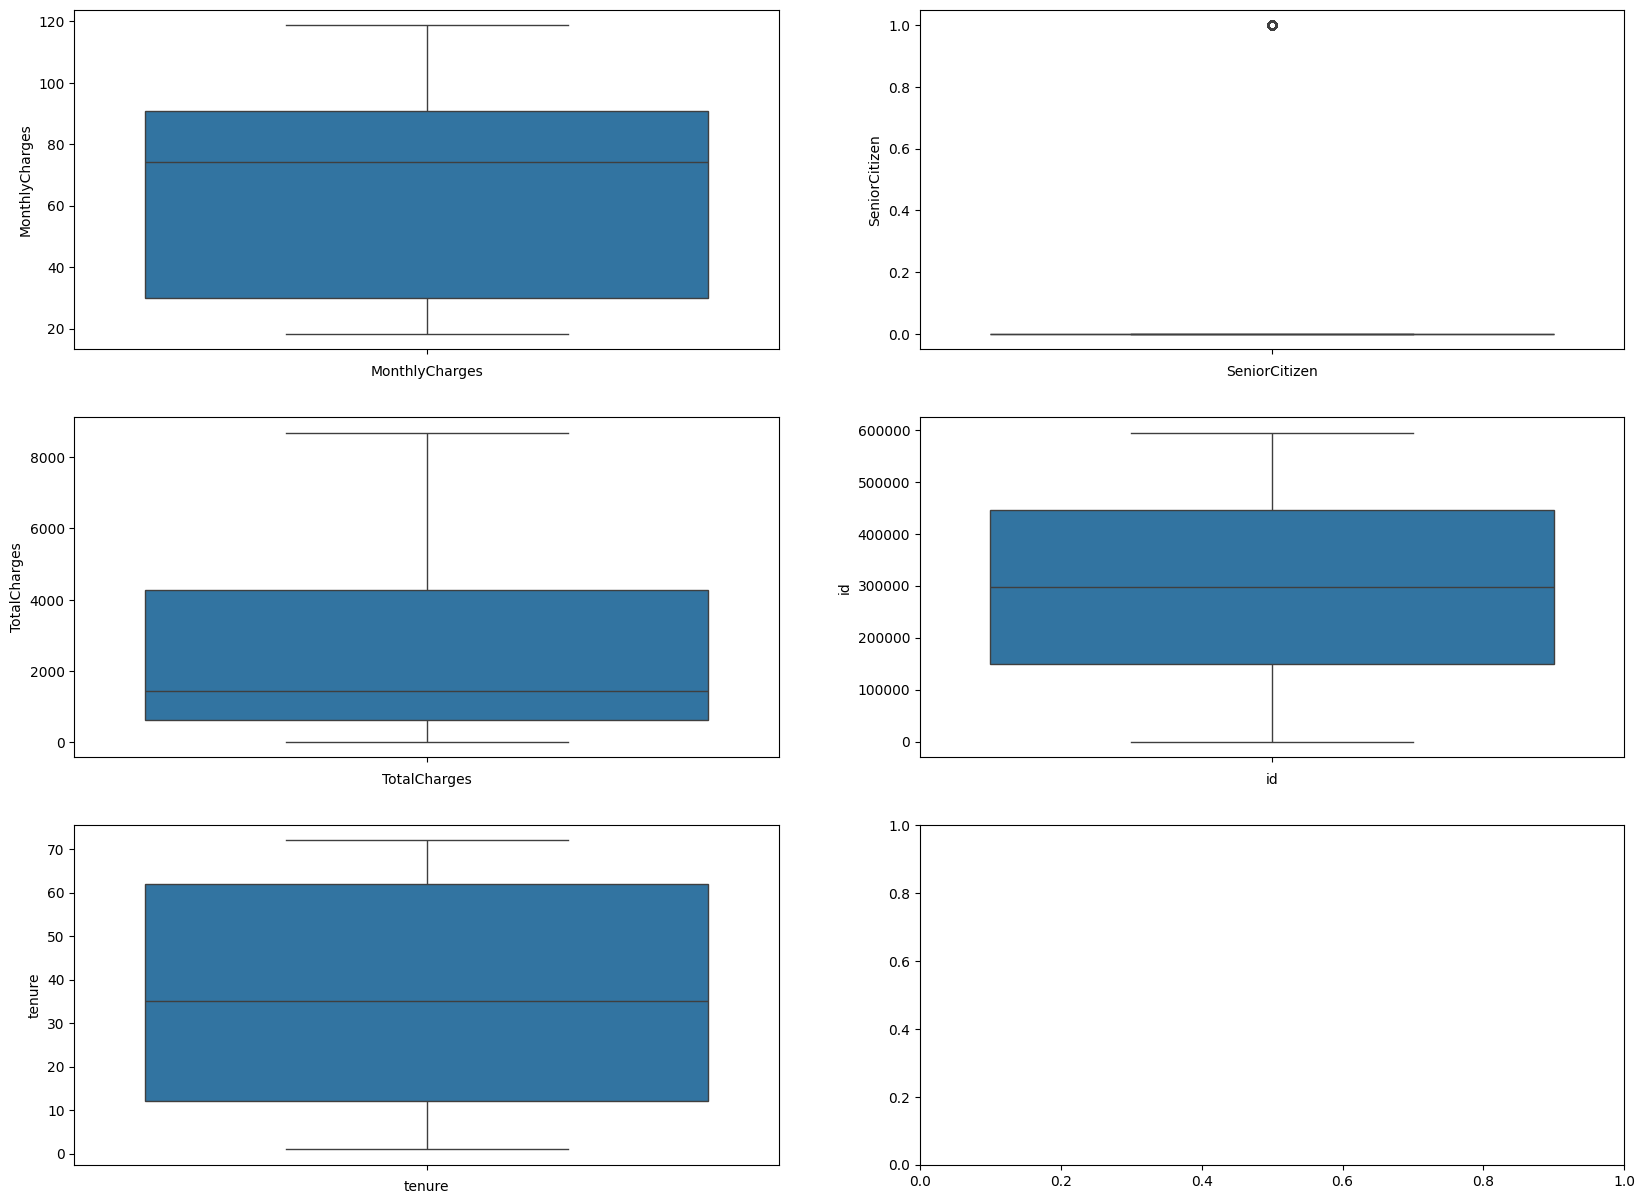

In [9]:
cols = ['MonthlyCharges', 'SeniorCitizen', 'TotalCharges', 'id', 'tenure']

fig, ax = plt.subplots(3, 2, figsize=(20, 15))
ax = ax.flatten()

for i, col in enumerate(cols):
    sns.boxplot(y=train[col], ax=ax[i])
    ax[i].set_xlabel(col)

## Categorical Column Analysis

In [ ]:
train['Churn'].isnull().sum()

np.int64(0)

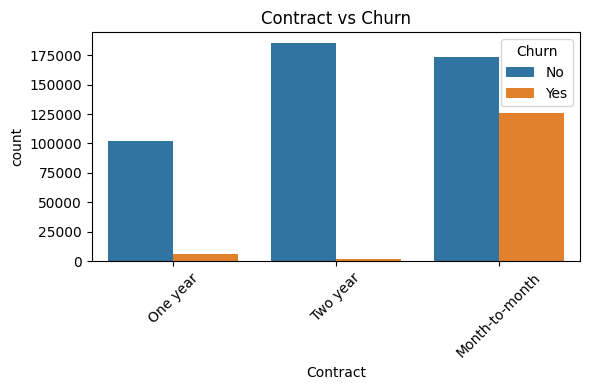

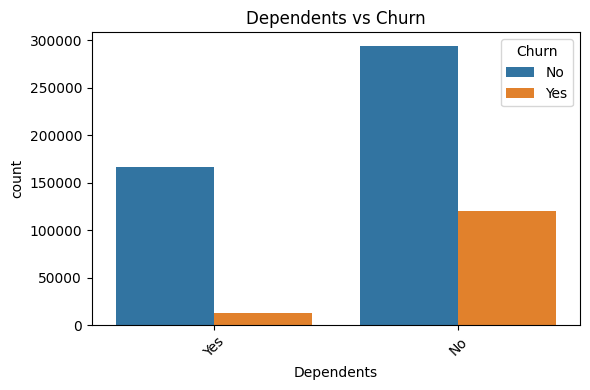

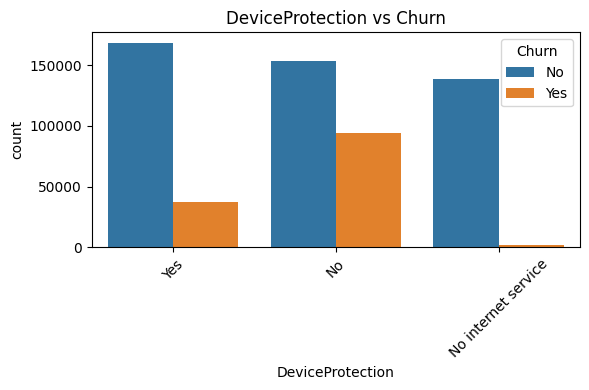

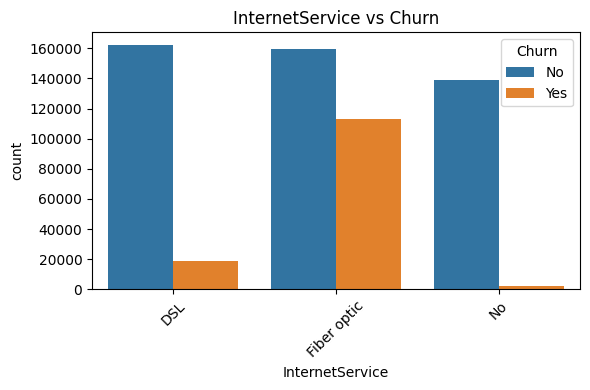

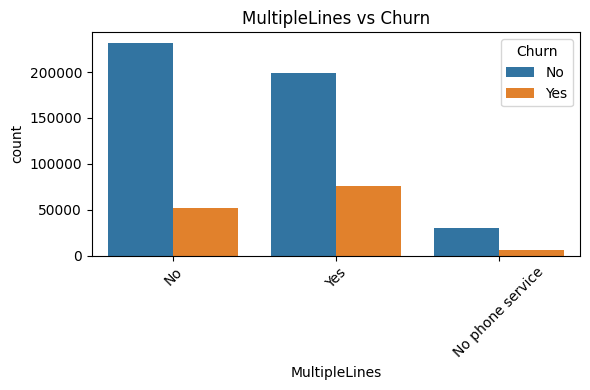

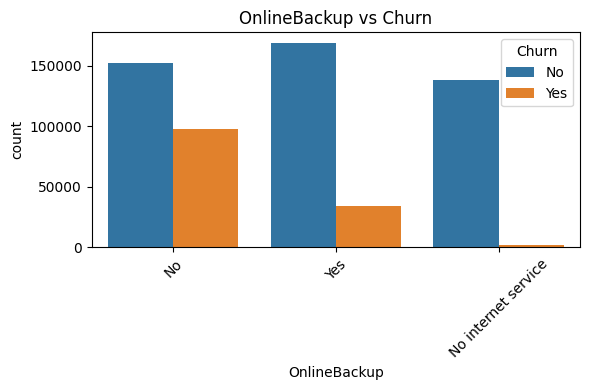

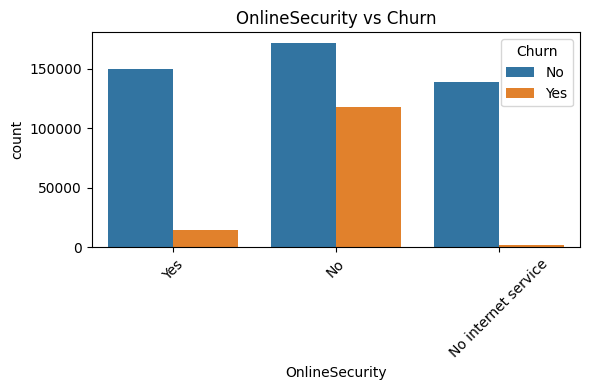

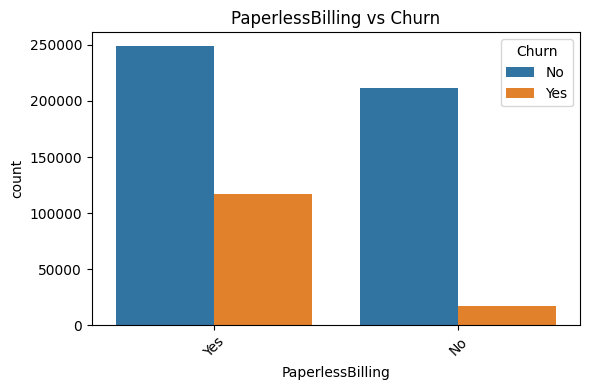

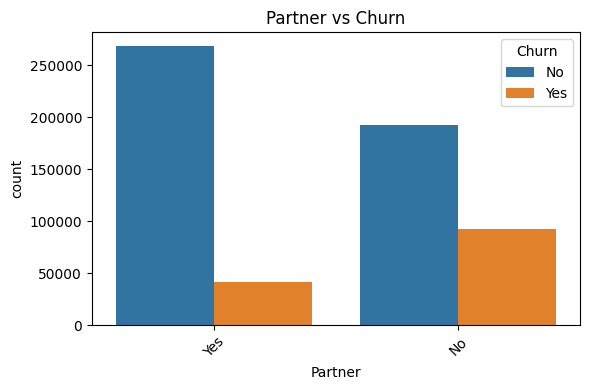

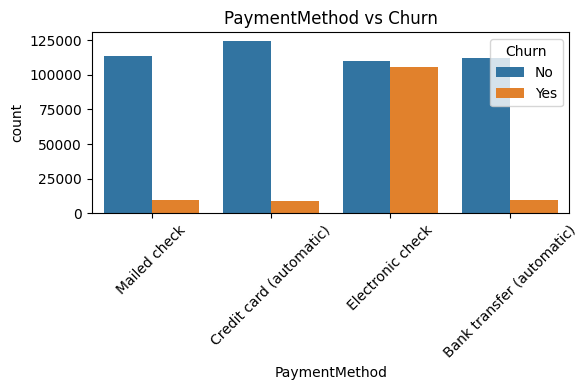

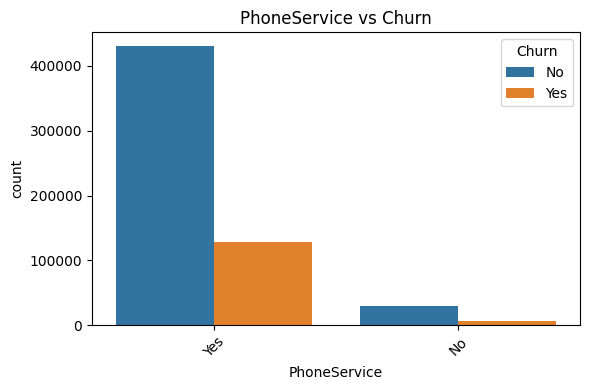

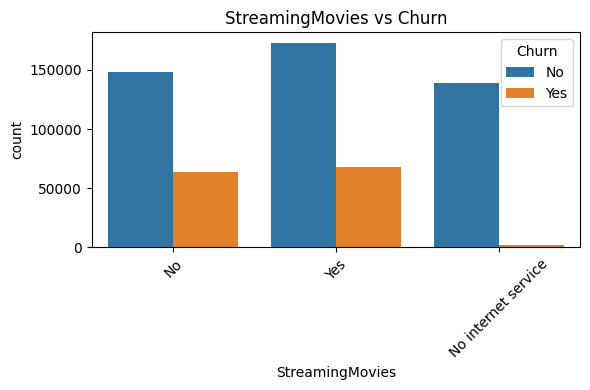

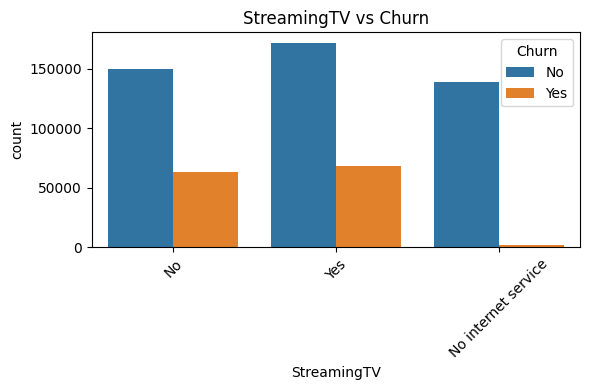

KeyboardInterrupt: 

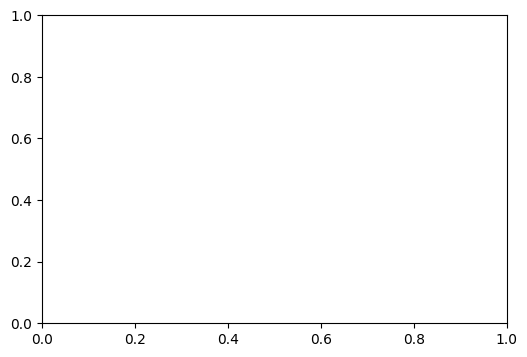

In [10]:
cat_cols = ['Contract', 'Dependents', 'DeviceProtection', 'InternetService',
            'MultipleLines', 'OnlineBackup', 'OnlineSecurity', 'PaperlessBilling',
            'Partner', 'PaymentMethod', 'PhoneService', 'StreamingMovies',
            'StreamingTV', 'TechSupport', 'gender']
for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(data=train, x=col, hue='Churn')
    plt.title(f"{col} vs Churn")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

##   EDA Output
1.   SeniorCitizen column is left skew and has outliers
2.   All Numeric Col required transformation
3.   All Categorical requeried encoding

## Training

In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.preprocessing import OneHotEncoder,LabelEncoder,PowerTransformer
from sklearn.model_selection import GridSearchCV
from lightgbm import LGBMClassifier

In [12]:
X_train,X_test,y_train,y_test = train_test_split(train.drop(columns=['Churn','id']),train['Churn'],test_size=0.2,random_state=42)

In [13]:
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [14]:
pd.DataFrame(y_train).value_counts()

0
0    368442
1    106913
Name: count, dtype: int64

In [57]:
X_train.sample(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
90665,Female,0,Yes,No,71,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),19.65,1292.15
428658,Male,0,No,No,13,Yes,Yes,Fiber optic,No,No,No,No,Yes,No,Month-to-month,Yes,Electronic check,86.20,1253.40
583188,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),116.10,8333.95


In [15]:

preprocessing = ColumnTransformer([
    ('ohe_pipe',Pipeline([('cat_col_ohe',OneHotEncoder(drop='first'))]),[0,2,3,5,6,7,8,9,10,11,12,13,14,15,16]),
    ('power_pipe',Pipeline([('power_transform',PowerTransformer())]),[1])
],remainder='passthrough')

In [16]:
model = Pipeline([
    ('preprocessing',preprocessing),
    ('lightgbm',LGBMClassifier())
])

In [33]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, PowerTransformer
from sklearn.metrics import classification_report, confusion_matrix
from hyperopt import hp, tpe, fmin, Trials, STATUS_OK
import matplotlib.pyplot as plt
import seaborn as sns

# 1. DEFINE YOUR PREPROCESSING
# Using your exact definition
preprocessing = ColumnTransformer([
    ('ohe_pipe', Pipeline([('cat_col_ohe', OneHotEncoder(drop='first', handle_unknown='ignore'))]), 
     [0, 2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]),
    ('power_pipe', Pipeline([('power_transform', PowerTransformer())]), [1])
], remainder='passthrough')

# 2. DEFINE THE HYPEROPT SEARCH SPACE
space = {
    'num_leaves': hp.quniform('num_leaves', 20, 150, 1),
    'learning_rate': hp.loguniform('learning_rate', np.log(0.01), np.log(0.2)),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1.0),
    'subsample': hp.uniform('subsample', 0.5, 1.0),
    'max_depth': hp.quniform('max_depth', 5, 15, 1),
    'min_child_samples': hp.quniform('min_child_samples', 10, 50, 1),
    'n_estimators' : hp.quniform('n_estimators', 20, 500, 1),
}

# 3. OBJECTIVE FUNCTION WITH PIPELINE
def objective(params):
    # Cast float to int for LightGBM
    params['num_leaves'] = int(params['num_leaves'])
    params['max_depth'] = int(params['max_depth'])
    params['min_child_samples'] = int(params['min_child_samples'])
    params['n_estimators'] = int(params['n_estimators'])
    
    
    # Define the full pipeline: Preprocessing -> Model
    # We use **params to pass the hyperopt suggestions to the classifier
    full_pipeline = Pipeline([
        ('pre', preprocessing),
        ('clf', lgb.LGBMClassifier(**params, random_state=42, verbose=-1, bagging_freq=5))
    ])
    
    # Calculate Cross-Validation Score (AUC)
    # n_jobs=-1 here will use all cores of your M4 Mac Mini
    score = cross_val_score(full_pipeline, X_train, y_train, cv=5, scoring='roc_auc', n_jobs=-1).mean()
    
    return {'loss': 1 - score, 'status': STATUS_OK}

# 4. RUN OPTIMIZATION
trials = Trials()
best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=200, trials=trials)

# 5. CREATE THE CHAMPION PIPELINE
# Re-casting the best parameters
final_params = best.copy()
for k in ['num_leaves', 'max_depth', 'min_child_samples', 'n_estimators']:
    final_params[k] = int(final_params[k])

champion_pipeline = Pipeline([
    ('pre', preprocessing),
    ('clf', lgb.LGBMClassifier(**final_params, random_state=42, verbose=-1))
])



  0%|          | 0/200 [00:00<?, ?trial/s, best loss=?]

/Users/rafael/miniconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/rafael/miniconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/rafael/miniconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/rafael/miniconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/rafael/miniconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature nam

  0%|          | 1/200 [00:44<2:26:58, 44.31s/trial, best loss: 0.08522039915031632]

/Users/rafael/miniconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/rafael/miniconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/rafael/miniconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/rafael/miniconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/rafael/miniconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature nam

  1%|          | 2/200 [01:36<2:42:17, 49.18s/trial, best loss: 0.08522039915031632]

...

 99%|█████████▉| 198/200 [53:48:23<42:24, 1272.31s/trial, best loss: 0.0840533959216817]  

/Users/rafael/miniconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/rafael/miniconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/rafael/miniconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/rafael/miniconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/rafael/miniconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature nam

100%|█████████▉| 199/200 [53:48:49<14:58, 898.50s/trial, best loss: 0.0840533959216817] 

/Users/rafael/miniconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/rafael/miniconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/rafael/miniconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/rafael/miniconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/rafael/miniconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature nam

100%|██████████| 200/200 [53:49:30<00:00, 968.85s/trial, best loss: 0.0840533959216817]


In [30]:
best

{'colsample_bytree': np.float64(0.7982244269659424),
 'learning_rate': np.float64(0.04337251608428162),
 'max_depth': np.float64(12.0),
 'min_child_samples': np.float64(14.0),
 'num_leaves': np.float64(73.0),
 'subsample': np.float64(0.7166907466677114)}

/Users/rafael/miniconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



   CHAMPION PIPELINE REPORT
              precision    recall  f1-score   support

           0       0.90      0.93      0.91     91935
           1       0.72      0.63      0.67     26904

    accuracy                           0.86    118839
   macro avg       0.81      0.78      0.79    118839
weighted avg       0.86      0.86      0.86    118839



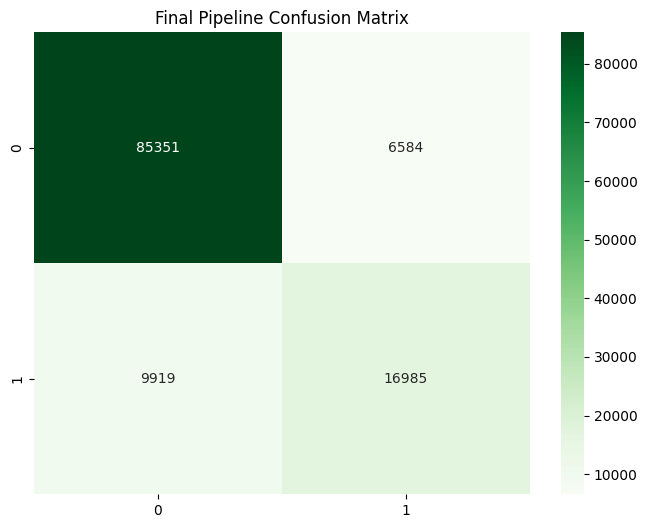

In [23]:
# 6. TRAIN AND EVALUATE
champion_pipeline.fit(X_train, y_train)
y_pred = champion_pipeline.predict(X_test)

# RESULTS
print("\n" + "="*30)
print("   CHAMPION PIPELINE REPORT")
print("="*30)
print(classification_report(y_test, y_pred))

# Confusion Matrix Visualization
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens')
plt.title('Final Pipeline Confusion Matrix')
plt.show()

In [ ]:
best_auc

0.9957675398157942

## Testing

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
model.predict_proba(X_test)

array([[0.99535169, 0.00464831],
       [0.99572335, 0.00427665],
       [0.99860581, 0.00139419],
       ...,
       [0.75471769, 0.24528231],
       [0.60812467, 0.39187533],
       [0.50368661, 0.49631339]])

In [ ]:
model.classes_

array([0, 1])

In [ ]:
churn_prob = model.predict_proba(test)[:,1]

In [ ]:
submission = pd.DataFrame({
    'id': test['id'],
    'Churn': churn_prob
})

In [ ]:
submission.to_csv('submission.csv', index=False)

In [26]:
from catboost import CatBoostClassifier
from sklearn.model_selection import GridSearchCV

# CatBoost can handle categorical features natively if we pass them, 
# but since we have a Pipeline with ColumnTransformer, we can use it, 
# or just use CatBoost directly on the dataframe.
# Here we'll use CatBoostClassifier directly with grid search.

cb_pipeline = Pipeline([
    ('pre', preprocessing),
    ('clf', CatBoostClassifier(random_state=42, verbose=0))
])

cb_params = {
    'clf__iterations': [100, 50],
    'clf__depth': [4, 6, 8],
    'clf__learning_rate': [0.01, 0.1]
}

grid_search = GridSearchCV(cb_pipeline, cb_params, cv=3, scoring='roc_auc', n_jobs=-1)
grid_search.fit(X_train, y_train)

print('Best CatBoost Params:', grid_search.best_params_)
print('Best CatBoost AUC:', grid_search.best_score_)

cb_best = grid_search.best_estimator_
cb_pred = cb_best.predict(X_test)
print(classification_report(y_test, cb_pred))


              precision    recall  f1-score   support

           0       0.90      0.93      0.91     91935
           1       0.72      0.64      0.67     26904

    accuracy                           0.86    118839
   macro avg       0.81      0.78      0.79    118839
weighted avg       0.86      0.86      0.86    118839



In [27]:
 grid_search.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('ohe_pipe', ...), ('power_pipe', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfo